# Clusterless per-spike diagnostics

Clusterless decoders skip spike sorting: each spike is described by its waveform
features (its *mark*), and the observation model is a joint intensity
$\lambda(x, y)$ of spikes with mark $y$ at position $x$. The paper's per-spike
diagnostics carry over:

- the spike's single-event likelihood is its mark's intensity normalized over
  positions, $Q(x) \propto \lambda(x, y_\text{obs})$, compared with the one-step
  prediction by **HPD overlap** and **KL divergence**;
- the **predictive p-value** ranks the observed mark's predictive density
  $f_\text{pred}(y) = \sum_x \lambda(x, y) P(x) / \sum_x \Lambda(x) P(x)$ among marks
  drawn from it. Marks are continuous, so it is estimated by Monte Carlo.

This tutorial decodes a simulated clusterless recording twice, with the true mark
model and with a misspecified one, and computes the diagnostics for every spike with
`clusterless_event_diagnostics`. It assumes the per-spike workflow of
[the previous tutorial](../05_per_event_diagnostics/).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

import statespacecheck as ssc

rng = np.random.default_rng(42)

## 1. A clusterless observation model

Eight units on a 100 cm track, each with a place field $r_u(x)$ and a waveform
amplitude drawn from $N(\mu_u, \sigma)$. Real waveform features have several
dimensions (one per channel); one keeps the example easy to plot, and the code is
the same for more. The joint mark intensity is

$$\lambda(x, y) = \sum_u r_u(x)\, N(y;\ \mu_u, \sigma),$$

and its integral over marks, the ground intensity, is $\Lambda(x) = \sum_u r_u(x)$.

`statespacecheck` takes the model as a `MarkModel` of three parts:

- `log_intensity`: $\log \lambda(x, y)$ of marks of shape `(n, 1)` at every
  position, shape `(n, n_bins)`. It is a log because densities of marks with many
  features are often too small to represent.
- `sample`: draws one mark for a spike at each given position bin: pick a unit in
  proportion to its rate there, then its amplitude.
- `ground_intensity`: $\Lambda(x)$.

In [2]:
dt = 0.02  # time-bin width (s)
n_time = 3000  # 60 s
position_bins = np.linspace(0, 100, 51)  # cm
n_units = 8
place_fields = 0.5 + 25.0 * np.exp(
    -0.5 * ((position_bins[:, None] - np.linspace(8, 92, n_units)) / 8.0) ** 2
)  # (n_bins, n_units), Hz
waveform_means = np.linspace(1.0, 5.2, n_units)  # 0.6 apart
waveform_std = 0.3


def clusterless_model(means: np.ndarray) -> ssc.MarkModel:
    """Return the MarkModel of units with ``place_fields`` and amplitude means ``means``."""
    cumulative = np.cumsum(place_fields / place_fields.sum(axis=1, keepdims=True), axis=1)

    def log_intensity(marks: np.ndarray) -> np.ndarray:
        # log sum_u r_u(x) N(y; mu_u, sigma), shape (n, n_bins). The largest log
        # density of each mark is factored out, so the sum over units is a matrix
        # product that cannot underflow
        log_amplitude = norm.logpdf(marks, means, waveform_std)  # (n, n_units)
        largest = log_amplitude.max(axis=1, keepdims=True)
        return largest + np.log(np.exp(log_amplitude - largest) @ place_fields.T)

    def sample(bins: np.ndarray, rng: np.random.Generator) -> np.ndarray:
        # A unit in proportion to its rate at each bin, then its amplitude
        u = rng.random(len(bins))
        unit = np.minimum((cumulative[bins] < u[:, np.newaxis]).sum(axis=1), n_units - 1)
        return rng.normal(means[unit], waveform_std)[:, np.newaxis]

    return ssc.MarkModel(log_intensity, sample, place_fields.sum(axis=1))


true_model = clusterless_model(waveform_means)

## 2. Simulate and decode

The animal runs back and forth; each unit fires Poisson spikes from its place field,
and each spike's mark is drawn from its unit's amplitude distribution. The unit is
kept for checking the results, but the decoder never sees it.

In [3]:
time = np.arange(n_time) * dt
true_position = 50 + 45 * np.sin(2 * np.pi * time / 12)
true_bin = np.abs(position_bins[:, None] - true_position).argmin(axis=0)

spike_counts = rng.poisson(place_fields[true_bin] * dt)  # (n_time, n_units)
time_bin, unit_ind = np.nonzero(spike_counts)
n_spikes = spike_counts[time_bin, unit_ind]
spike_time_ind = np.repeat(time_bin, n_spikes)  # (n_spikes,)
spike_unit = np.repeat(unit_ind, n_spikes)
spike_marks = rng.normal(waveform_means[spike_unit], waveform_std)[:, np.newaxis]
print(f"{spike_marks.shape[0]} spikes")

2631 spikes


The decoder is a grid filter, as in the previous tutorial, with the clusterless
Poisson likelihood of a time bin,
$e^{-\Lambda(x)\,\Delta t} \prod_j \lambda(x, y_j)\,\Delta t$. It returns the
one-step predictive distribution $P_k(x) = p(x_k \mid y_{1:k-1})$ of every time bin.

In [4]:
def decode(model: ssc.MarkModel) -> np.ndarray:
    """Return the one-step predictive distribution of a grid filter, (n_time, n_bins)."""
    step = position_bins[:, None] - position_bins[None, :]
    transition = np.exp(-0.5 * (step / 3.0) ** 2)
    transition /= transition.sum(axis=0, keepdims=True)  # column x' -> x

    log_likelihood = np.tile(-model.ground_intensity * dt, (n_time, 1))
    np.add.at(log_likelihood, spike_time_ind, model.log_intensity(spike_marks))

    predictive = np.empty((n_time, position_bins.size))
    posterior = np.full(position_bins.size, 1 / position_bins.size)
    for k in range(n_time):
        predictive[k] = transition @ posterior
        log_posterior = np.log(predictive[k]) + log_likelihood[k]
        posterior = np.exp(log_posterior - log_posterior.max())
        posterior /= posterior.sum()
    return predictive


predictive = decode(true_model)

The misspecified decoder believes every unit's amplitude is 0.8 higher than it is,
as if the waveform features had been estimated on a recording whose amplitudes have
since drifted by a constant offset.

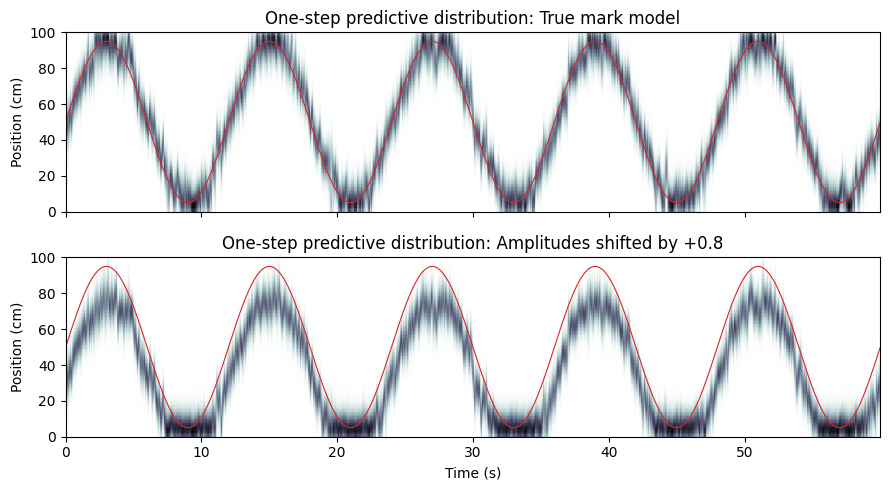

In [5]:
misspecified_model = clusterless_model(waveform_means + 0.8)
misspecified_predictive = decode(misspecified_model)

fig, axes = plt.subplots(2, 1, sharex=True, sharey=True, figsize=(9, 5))
for ax, values, title in zip(
    axes,
    [predictive, misspecified_predictive],
    ["True mark model", "Amplitudes shifted by +0.8"],
    strict=True,
):
    ax.imshow(
        values.T,
        aspect="auto",
        origin="lower",
        extent=(time[0], time[-1], position_bins[0], position_bins[-1]),
        cmap="bone_r",
    )
    ax.plot(time, true_position, color="tab:red", linewidth=0.8)
    ax.set(ylabel="Position (cm)", title=f"One-step predictive distribution: {title}")
axes[-1].set_xlabel("Time (s)")
fig.tight_layout()
plt.show()

## 3. Diagnostics for every spike

`clusterless_event_diagnostics` takes the predictive distribution, the `MarkModel`,
and the time bin and mark of each spike. The p-value uses 1,000 replicated marks per
spike by default; its Monte Carlo standard error is $\sqrt{p(1-p)/1000}$, under
0.007 near the 0.05 cutoff. Fixing the seed makes the results reproducible.

In [6]:
diagnostics = ssc.clusterless_event_diagnostics(
    predictive, true_model, spike_time_ind, spike_marks, rng=0
)
misspecified = ssc.clusterless_event_diagnostics(
    misspecified_predictive, misspecified_model, spike_time_ind, spike_marks, rng=0
)
print(f"{'':13s} p <= 0.05   HPD overlap = 1   median KL")
for name, result in [("true model", diagnostics), ("misspecified", misspecified)]:
    print(
        f"{name:13s} {np.mean(result.predictive_pvalue <= 0.05):9.1%} "
        f"{np.mean(result.hpd_overlap == 1):17.1%} {np.median(result.kl_divergence):11.2f}"
    )

              p <= 0.05   HPD overlap = 1   median KL
true model         5.5%             82.5%        0.44
misspecified      13.0%             83.5%        0.36


## 4. What the diagnostics show

With the true mark model, 5.5% of spikes have $p \le 0.05$, about the 5% expected
of a model that fits, and the histogram of p-values is nearly flat. (The random-walk
state model only approximates the animal's running, so it need not be exactly flat.)
With the misspecified model, 13% do, and the histogram rises toward 0.

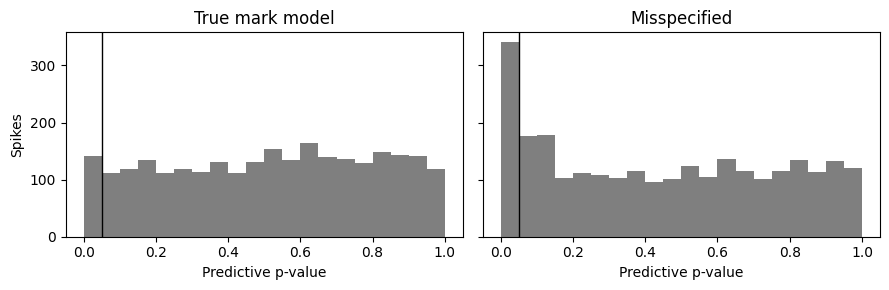

In [7]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(9, 3))
bins = np.linspace(0, 1, 21)
for ax, (title, result) in zip(
    axes, [("True mark model", diagnostics), ("Misspecified", misspecified)], strict=True
):
    ax.hist(result.predictive_pvalue, bins=bins, color="tab:gray")
    ax.axvline(0.05, color="k", linewidth=1)
    ax.set(xlabel="Predictive p-value", title=title)
axes[0].set_ylabel("Spikes")
fig.tight_layout()
plt.show()

Per spike, over time (p-values of 0, when no replicated mark was as unlikely as the
observed one, are drawn at $1/1000$, the resolution of 1,000 replicates):

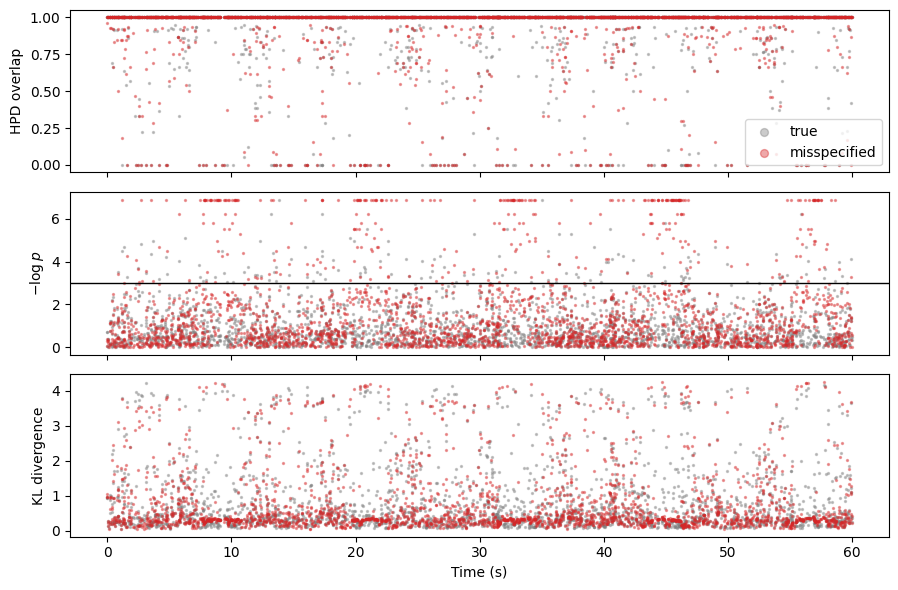

In [8]:
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(9, 6))
for label, result, color in [
    ("true", diagnostics, "tab:gray"),
    ("misspecified", misspecified, "tab:red"),
]:
    spike_time = time[spike_time_ind]
    axes[0].scatter(spike_time, result.hpd_overlap, s=2, alpha=0.4, color=color, label=label)
    axes[1].scatter(
        spike_time,
        -np.log(np.maximum(result.predictive_pvalue, 1e-3)),
        s=2,
        alpha=0.4,
        color=color,
    )
    axes[2].scatter(spike_time, result.kl_divergence, s=2, alpha=0.4, color=color)
axes[0].set_ylabel("HPD overlap")
axes[1].set_ylabel("$-\\log p$")
axes[1].axhline(-np.log(0.05), color="k", linewidth=1)
axes[2].set(ylabel="KL divergence", xlabel="Time (s)")
axes[0].legend(loc="lower right", markerscale=4)
fig.tight_layout()
plt.show()

Most of the small p-values of the misspecified model cluster in time, each time the
animal is near the start of the track, while HPD overlap and KL divergence barely
change: KL divergence is even a little lower. Real clusterless data have no unit
labels, but the flags can be broken down by the marks themselves, here by amplitude:

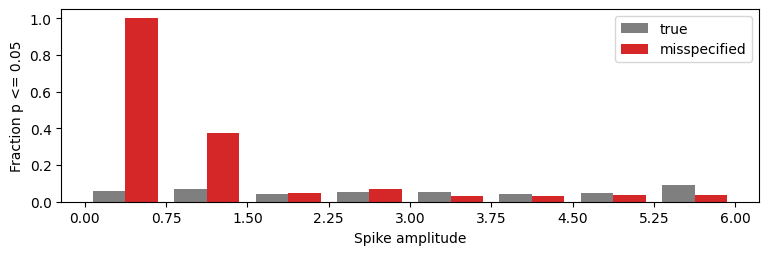

In [9]:
amplitude_edges = np.arange(0.0, 6.01, 0.75)
amplitude_bin = np.digitize(spike_marks[:, 0], amplitude_edges[1:-1])  # 0 .. 7
fig, ax = plt.subplots(figsize=(9, 2.5))
width = 0.3
for offset, (label, result, color) in zip(
    [-width / 2, width / 2],
    [("true", diagnostics, "tab:gray"), ("misspecified", misspecified, "tab:red")],
    strict=True,
):
    flagged = [
        np.mean(result.predictive_pvalue[amplitude_bin == k] <= 0.05)
        for k in range(amplitude_edges.size - 1)
    ]
    ax.bar(amplitude_edges[:-1] + 0.375 + offset, flagged, width, color=color, label=label)
ax.set(xlabel="Spike amplitude", ylabel="Fraction p <= 0.05", xticks=amplitude_edges)
ax.legend()
plt.show()

The misfit is in the spikes of the lowest amplitudes. The simulation knows which unit
fired each spike, so it can tell why:

In [10]:
for name, result in [("true", diagnostics), ("misspecified", misspecified)]:
    flagged = [
        np.mean(result.predictive_pvalue[spike_unit == u] <= 0.05) for u in range(n_units)
    ]
    print(f"{name:13s} fraction p <= 0.05 by unit:", np.round(flagged, 2))

true          fraction p <= 0.05 by unit: [0.06 0.05 0.05 0.06 0.05 0.06 0.05 0.06]
misspecified  fraction p <= 0.05 by unit: [0.55 0.08 0.05 0.08 0.04 0.02 0.04 0.03]


The shift of 0.8 is larger than the 0.6 spacing of the units' amplitudes, so each
spike of unit $u$ looks most like what the misspecified model expects of unit
$u - 1$, whose place field is 12 cm lower. The decoder reads it as that unit's spike
and places the animal lower on the track, as in the predictive distribution plotted
above. Its prediction for the next spikes comes from the same misspecified model, so
they agree with it: the prediction and each spike's likelihood stay consistent, and
HPD overlap, KL divergence and most p-values look like a good fit. Unit 0's
amplitudes, near 1.0, lie below every amplitude the misspecified model expects (1.8
and up), so no unit explains them: more than half of its spikes are flagged, against
at most 8% for any other unit. Its place field is at the start of the track, which
is where the flags appeared in time.

The diagnostics measure whether each spike is consistent with the decoder's
prediction, not whether the decoded position is right. A systematic error that the
model absorbs consistently shows only where it breaks: here, at the edge of the
mark space, which breaking the flags down by mark value finds.

## 5. The sorted special case

With a finite set of marks, such as sorted units, `event_diagnostics` computes the
same diagnostics exactly. Written as a `MarkModel` of integer marks, the units give
`clusterless_event_diagnostics` the same HPD overlap and KL divergence, bit for bit,
and p-values within Monte Carlo error.

In [11]:
unit_cumulative = np.cumsum(place_fields / place_fields.sum(axis=1, keepdims=True), axis=1)


def sample_unit(bins: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    """Draw a unit for a spike at each position bin, in proportion to its rate there."""
    u = rng.random(len(bins))
    return np.minimum((unit_cumulative[bins] < u[:, np.newaxis]).sum(axis=1), n_units - 1)


sorted_model = ssc.MarkModel(
    log_intensity=lambda units: np.log(place_fields[:, units].T),  # (n, n_bins)
    sample=sample_unit,
    ground_intensity=place_fields.sum(axis=1),
)
monte_carlo = ssc.clusterless_event_diagnostics(
    predictive, sorted_model, spike_time_ind, spike_unit, rng=0
)
exact = ssc.event_diagnostics(predictive, place_fields, spike_time_ind, spike_unit)

assert np.array_equal(monte_carlo.hpd_overlap, exact.hpd_overlap)
assert np.array_equal(monte_carlo.kl_divergence, exact.kl_divergence)
standard_error = np.sqrt(exact.predictive_pvalue * (1 - exact.predictive_pvalue) / 1000)
z = (monte_carlo.predictive_pvalue - exact.predictive_pvalue) / np.maximum(
    standard_error, 1e-3
)
print(f"largest |p-value difference| / standard error: {np.abs(z).max():.1f}")

largest |p-value difference| / standard error: 3.5


The p-values differ by at most a few standard errors, as expected of 1,000
replicates for each of about 2,600 spikes. For sorted units, `event_diagnostics` is
exact and much faster, so use it; `clusterless_event_diagnostics` is for marks that
cannot be enumerated.

## Next steps

- [Using statespacecheck with your decoder](../../decoders/): a `MarkModel` for
  `non_local_detector`'s clusterless KDE model.
- [Interpreting the diagnostics](../../interpretation/).
- The API reference for `clusterless_event_diagnostics`, `MarkModel` and
  `monte_carlo_mark_pvalue`.